In [1]:
!pip install gradio-client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 5.0 MB/s eta 0:00:00


Saving mb_1675241802881380.jpg to mb_1675241802881380.jpg


Saving 01449_00.jpg to 01449_00 (3).jpg
Loaded as API: https://franciszzj-leffa.hf.space ✔


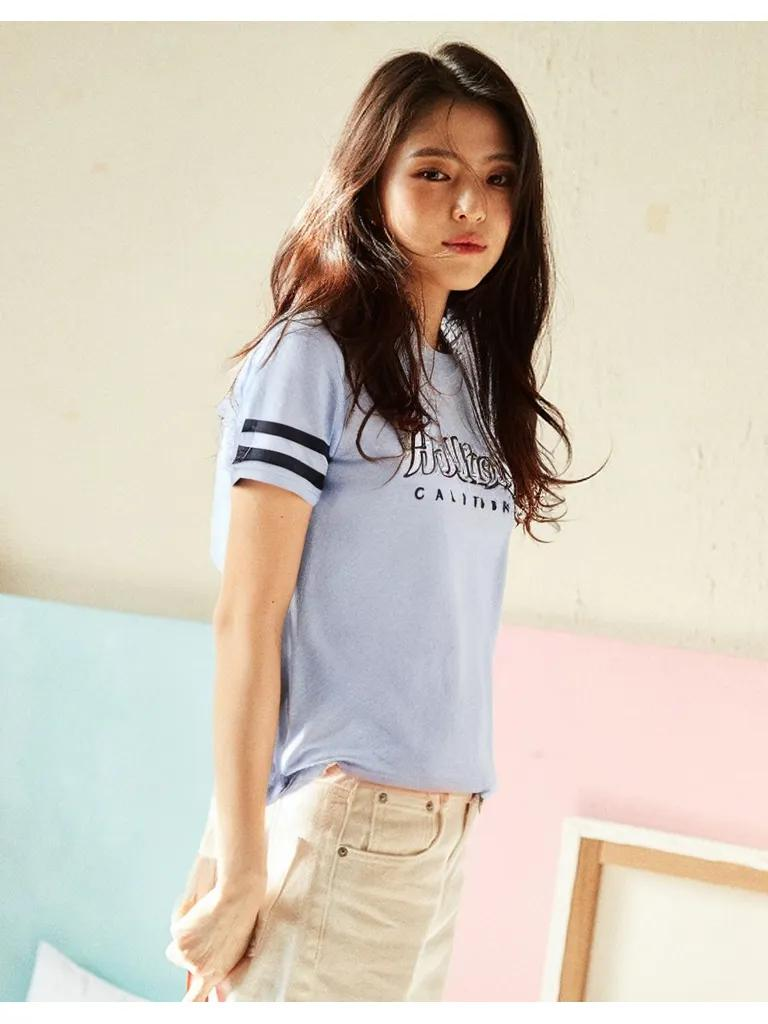

In [5]:
# 첫 번째 파일 업로드
from google.colab import files
uploaded = files.upload()

# 업로드된 파일 확인
person_image = '/content/' + list(uploaded.keys())[0]  # 첫 번째 업로드된 파일

# 두 번째 파일 업로드
uploaded = files.upload()  # 다시 파일을 업로드하는 부분
garment_image = '/content/' + list(uploaded.keys())[0]  # 두 번째 업로드된 파일

# 클라이언트 객체 생성
from gradio_client import Client, handle_file

client = Client("franciszzj/Leffa")

# 예시로 person.jpg와 garment.jpg 사용
result = client.predict(
    src_image_path=handle_file(person_image),
    ref_image_path=handle_file(garment_image),
    ref_acceleration=True,
    step=40,
    scale=2.5,
    seed=42,
    vt_model_type="viton_hd",
    vt_garment_type="upper_body",
    vt_repaint=True,
    api_name="/leffa_predict_vt"
)

from PIL import Image as PILImage
from IPython.display import display

# 웹P 이미지를 JPEG로 변환
output_image_path = result[0]  # result의 첫 번째 값이 이미지 경로일 경우

# 웹P 이미지를 열고 JPEG로 변환하여 저장
webp_image = PILImage.open(output_image_path)
jpeg_output_path = '/content/output_image.jpg'
webp_image.convert('RGB').save(jpeg_output_path, 'JPEG')

# 변환된 JPEG 이미지를 표시
display(PILImage.open(jpeg_output_path))